In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [33]:
df = pd.read_csv('Rent-Data.csv', skiprows=1, na_values=["-", "**"])
df.drop('Unnamed: 4', axis=1, inplace=True)
df["Estimate!!Median gross rent"] = pd.to_numeric(df["Estimate!!Median gross rent"], errors="coerce")
df["Margin of Error!!Median gross rent"] = pd.to_numeric(df["Margin of Error!!Median gross rent"], errors="coerce")
df.head()

,Geography,Geographic Area Name,Estimate!!Median gross rent,Margin of Error!!Median gross rent
0,1400000US01001020100,Census Tract 201; Autauga County; Alabama,1049.0,99.0
1,1400000US01001020200,Census Tract 202; Autauga County; Alabama,897.0,270.0
2,1400000US01001020300,Census Tract 203; Autauga County; Alabama,1035.0,174.0
3,1400000US01001020400,Census Tract 204; Autauga County; Alabama,1048.0,434.0
4,1400000US01001020501,Census Tract 205.01; Autauga County; Alabama,1614.0,439.0


In [34]:
df[['tract', 'county', 'state']] = df['Geographic Area Name'].str.split(';', expand=True)
df[['tract', 'county', 'state']] = df[['tract', 'county', 'state']].apply(lambda x: x.str.strip())

df.drop(columns=['Geographic Area Name'], inplace=True)
df

,Geography,Estimate!!Median gross rent,Margin of Error!!Median gross rent,tract,county,state
0,1400000US01001020100,1049.0,99.0,Census Tract 201,Autauga County,Alabama
1,1400000US01001020200,897.0,270.0,Census Tract 202,Autauga County,Alabama
2,1400000US01001020300,1035.0,174.0,Census Tract 203,Autauga County,Alabama
3,1400000US01001020400,1048.0,434.0,Census Tract 204,Autauga County,Alabama
4,1400000US01001020501,1614.0,439.0,Census Tract 205.01,Autauga County,Alabama
...,...,...,...,...,...,...
85377,1400000US72153750501,551.0,74.0,Census Tract 7505.01,Yauco Municipio,Puerto Rico
85378,1400000US72153750502,229.0,221.0,Census Tract 7505.02,Yauco Municipio,Puerto Rico
85379,1400000US72153750503,668.0,168.0,Census Tract 7505.03,Yauco Municipio,Puerto Rico
85380,1400000US72153750601,747.0,217.0,Census Tract 7506.01,Yauco Municipio,Puerto Rico


In [35]:
df['geoid'] = df['Geography'].str.extract(r'US(\d{5})')
df['geoid_tract'] = df['Geography'].str.extract(r'US(\d+)')
df.drop(columns=['Geography'], inplace=True)
df

,Estimate!!Median gross rent,Margin of Error!!Median gross rent,tract,county,state,geoid,geoid_tract
0,1049.0,99.0,Census Tract 201,Autauga County,Alabama,01001,01001020100
1,897.0,270.0,Census Tract 202,Autauga County,Alabama,01001,01001020200
2,1035.0,174.0,Census Tract 203,Autauga County,Alabama,01001,01001020300
3,1048.0,434.0,Census Tract 204,Autauga County,Alabama,01001,01001020400
4,1614.0,439.0,Census Tract 205.01,Autauga County,Alabama,01001,01001020501
...,...,...,...,...,...,...,...
85377,551.0,74.0,Census Tract 7505.01,Yauco Municipio,Puerto Rico,72153,72153750501
85378,229.0,221.0,Census Tract 7505.02,Yauco Municipio,Puerto Rico,72153,72153750502
85379,668.0,168.0,Census Tract 7505.03,Yauco Municipio,Puerto Rico,72153,72153750503
85380,747.0,217.0,Census Tract 7506.01,Yauco Municipio,Puerto Rico,72153,72153750601


In [36]:
df["Estimate!!Median gross rent"] = pd.to_numeric(df["Estimate!!Median gross rent"], errors="coerce")
df["Margin of Error!!Median gross rent"] = pd.to_numeric(df["Margin of Error!!Median gross rent"], errors="coerce")
df = df.rename(columns={'Estimate!!Median gross rent': 'median_rent', 'Margin of Error!!Median gross rent': 'median_rent_moe'})
df

,median_rent,median_rent_moe,tract,county,state,geoid,geoid_tract
0,1049.0,99.0,Census Tract 201,Autauga County,Alabama,01001,01001020100
1,897.0,270.0,Census Tract 202,Autauga County,Alabama,01001,01001020200
2,1035.0,174.0,Census Tract 203,Autauga County,Alabama,01001,01001020300
3,1048.0,434.0,Census Tract 204,Autauga County,Alabama,01001,01001020400
4,1614.0,439.0,Census Tract 205.01,Autauga County,Alabama,01001,01001020501
...,...,...,...,...,...,...,...
85377,551.0,74.0,Census Tract 7505.01,Yauco Municipio,Puerto Rico,72153,72153750501
85378,229.0,221.0,Census Tract 7505.02,Yauco Municipio,Puerto Rico,72153,72153750502
85379,668.0,168.0,Census Tract 7505.03,Yauco Municipio,Puerto Rico,72153,72153750503
85380,747.0,217.0,Census Tract 7506.01,Yauco Municipio,Puerto Rico,72153,72153750601


In [37]:
df.isna().sum()

,0
median_rent,6633
median_rent_moe,6633
tract,0
county,0
state,0
geoid,0
geoid_tract,0


In [38]:
df.describe()

,median_rent,median_rent_moe
count,78749.000000,78749.000000
mean,1432.478127,266.344423
std,596.502406,261.524518
min,152.000000,4.000000
25%,965.000000,114.000000
50%,1313.000000,185.000000
75%,1790.000000,315.000000
max,3500.000000,3140.000000


In [39]:
suplement_data = {'state': ['California', 'Florida', 'Georgia', 'Michigan', 'Missouri', 'North Carolina', 'Oklahoma', 'South Carolina', 'Tennessee', 'Texas', 'Virginia', 'Alabama', 'Arkansas', 'Illinois', 'Indiana', 'Kentucky', 'Louisiana', 'Mississippi', 'New Jersey', 'Ohio', 'Pennsylvania', 'West Virginia', 'Wisconsin', 'Alaska', 'Arizona', 'Colorado', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Iowa', 'Kansas', 'Maine', 'Maryland', 'Massachusetts', 'Minnesota', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Dakota', 'Oregon', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Washington', 'Wyoming'],
                  'employee1_mean': [256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000],
                  'employee1_sd': [4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660]
                  }
df2 = pd.DataFrame(suplement_data)
df2

,state,employee1_mean,employee1_sd
0,California,256830,4109
1,Florida,256830,4109
2,Georgia,256830,4109
3,Michigan,256830,4109
4,Missouri,256830,4109
5,North Carolina,256830,4109
6,Oklahoma,256830,4109
7,South Carolina,256830,4109
8,Tennessee,256830,4109
9,Texas,256830,4109


In [40]:
result = df.merge(df2, on='state', how='left')
result.to_csv('tract_lvl_finance.csv', index=False)

In [41]:
pop_df = pd.read_csv('all_merged.csv')

pop_df = pop_df[['geoid', 'total_population', 'total_population_poverty']]
pop_df.groupby('geoid').sum()

,total_population,total_population_poverty
geoid,,
1001,717108.0,83856.0
1003,7639485.0,936045.0
1005,222354.0,52740.0
1007,88020.0,15916.0
1009,535608.0,72198.0
...,...,...
56037,496140.0,60468.0
56039,93148.0,4848.0
56041,62136.0,6621.0


In [172]:
flat = result.groupby("geoid").agg(
    county=("county", "first"),
    state=("state", "first"),
    median_rent=("median_rent", "mean"),
    median_rent_moe=("median_rent_moe", "mean"),
    employee1_mean=("employee1_mean", "first"),
    employee1_sd=("employee1_sd", "first")
).reset_index()
flat['geoid'] = flat['geoid'].astype(int)

county = flat.merge(pop_df, on="geoid", how="left")
county.drop_duplicates(inplace=True)
county.reset_index(drop=True, inplace=True)
county

,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty
0,1001,Autauga County,Alabama,1125.785714,268.857143,156000.0,660.0,59759.0,6988.0
1,1003,Baldwin County,Alabama,1313.023810,267.142857,156000.0,660.0,246435.0,30195.0
2,1005,Barbour County,Alabama,733.222222,142.555556,156000.0,660.0,24706.0,5860.0
3,1007,Bibb County,Alabama,887.875000,362.625000,156000.0,660.0,22005.0,3979.0
4,1009,Blount County,Alabama,825.750000,142.125000,156000.0,660.0,59512.0,8022.0
...,...,...,...,...,...,...,...,...,...
3217,72145,Vega Baja Municipio,Puerto Rico,656.923077,219.076923,NaN,NaN,NaN,NaN
3218,72147,Vieques Municipio,Puerto Rico,461.000000,89.000000,NaN,NaN,NaN,NaN
3219,72149,Villalba Municipio,Puerto Rico,552.000000,198.500000,NaN,NaN,NaN,NaN
3220,72151,Yabucoa Municipio,Puerto Rico,544.555556,118.333333,NaN,NaN,NaN,NaN


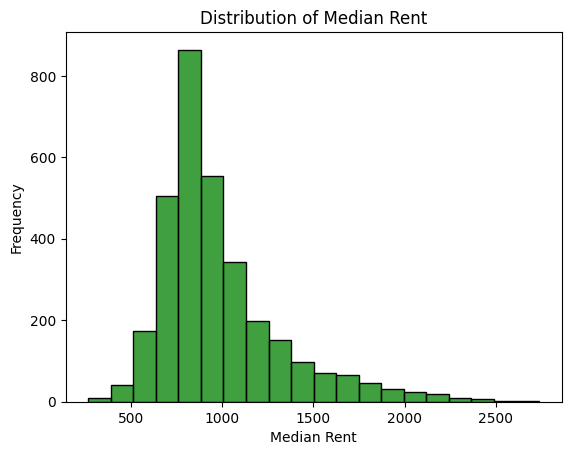

In [244]:
sns.histplot(county['median_rent'], bins=20, color='green')
plt.xlabel('Median Rent')
plt.ylabel('Frequency')
plt.title('Distribution of Median Rent')
plt.savefig("hist_med_rent.png", dpi=300, bbox_inches="tight")
plt.show()

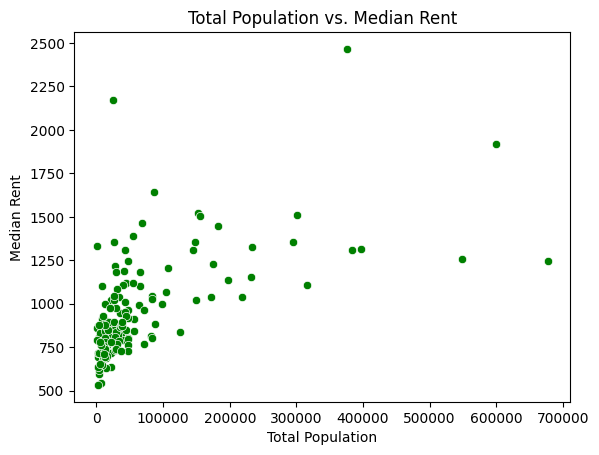

In [245]:
np.random.seed(30)
sns.scatterplot(x='total_population', y='median_rent', data=county.sample(150), color='green')
plt.xlabel('Total Population')
plt.ylabel('Median Rent')
plt.title('Total Population vs. Median Rent')
plt.savefig("TpVsMr.png", dpi=300, bbox_inches="tight")
plt.show()

In [246]:
class FinanceCalc:
  def __init__(self, emp_1, emp_extra, rn, rent, count, sub_price):
    self.emp_1 = emp_1
    self.rn = rn
    self.emp_extra = emp_extra
    self.rent = rent
    self.count = count
    self.sub_price = sub_price

  def employee_cost(self):
    amount = self.count
    cost = self.emp_1 + (self.emp_extra*3)
    step = 1

    while amount > 400:
      cost += self.rn
      if step % 2 == 0:
        cost += self.emp_extra
      step += 1
      amount -= 400
    return cost

  def total_cost(self):
    return ((self.employee_cost() + (self.rent*12)) + 15000 + 15000 + 20000)*5

  def roi_percent(self):
    return ((((self.count * self.sub_price * 12)*5) - self.total_cost())/self.total_cost())*100

In [232]:
test = county.sample()
model = FinanceCalc(test['employee1_mean'].values[0], 45580, 132000, test['median_rent'].values[0], 400, 100)
print(test['county'].values[0], model.roi_percent())

Fisher County 6.511396719448981


In [233]:
georgia = county[county["state"] == "Georgia"]

georgia["roi"] = georgia.apply(lambda row: FinanceCalc(
    emp_1=row["employee1_mean"],
    emp_extra=45580,
    rn=132000,
    rent=row["median_rent"],
    count=(row["total_population"]*.02),
    sub_price=100
).roi_percent(), axis=1)

georgia

/tmp/ipykernel_5435/1940715503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  georgia["roi"] = georgia.apply(lambda row: FinanceCalc(


,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,roi
389,13001,Appling County,Georgia,819.333333,338.833333,256830.0,4109.0,18428.0,3644.0,-2.454775
390,13003,Atkinson County,Georgia,703.333333,154.333333,256830.0,4109.0,8183.0,1717.0,-56.551404
391,13005,Bacon County,Georgia,714.000000,143.333333,256830.0,4109.0,11191.0,2485.0,-40.596897
392,13007,Baker County,Georgia,603.000000,290.500000,256830.0,4109.0,2788.0,599.0,-85.157252
393,13009,Baldwin County,Georgia,928.769231,223.307692,256830.0,4109.0,43635.0,9253.0,37.020350
...,...,...,...,...,...,...,...,...,...,...
543,13313,Whitfield County,Georgia,984.727273,199.318182,256830.0,4109.0,103132.0,13161.0,105.144811
544,13315,Wilcox County,Georgia,594.000000,158.500000,256830.0,4109.0,8761.0,1790.0,-53.347031
545,13317,Wilkes County,Georgia,858.250000,103.250000,256830.0,4109.0,9599.0,1766.0,-49.241742
546,13319,Wilkinson County,Georgia,867.333333,165.333333,256830.0,4109.0,8681.0,1456.0,-54.107027


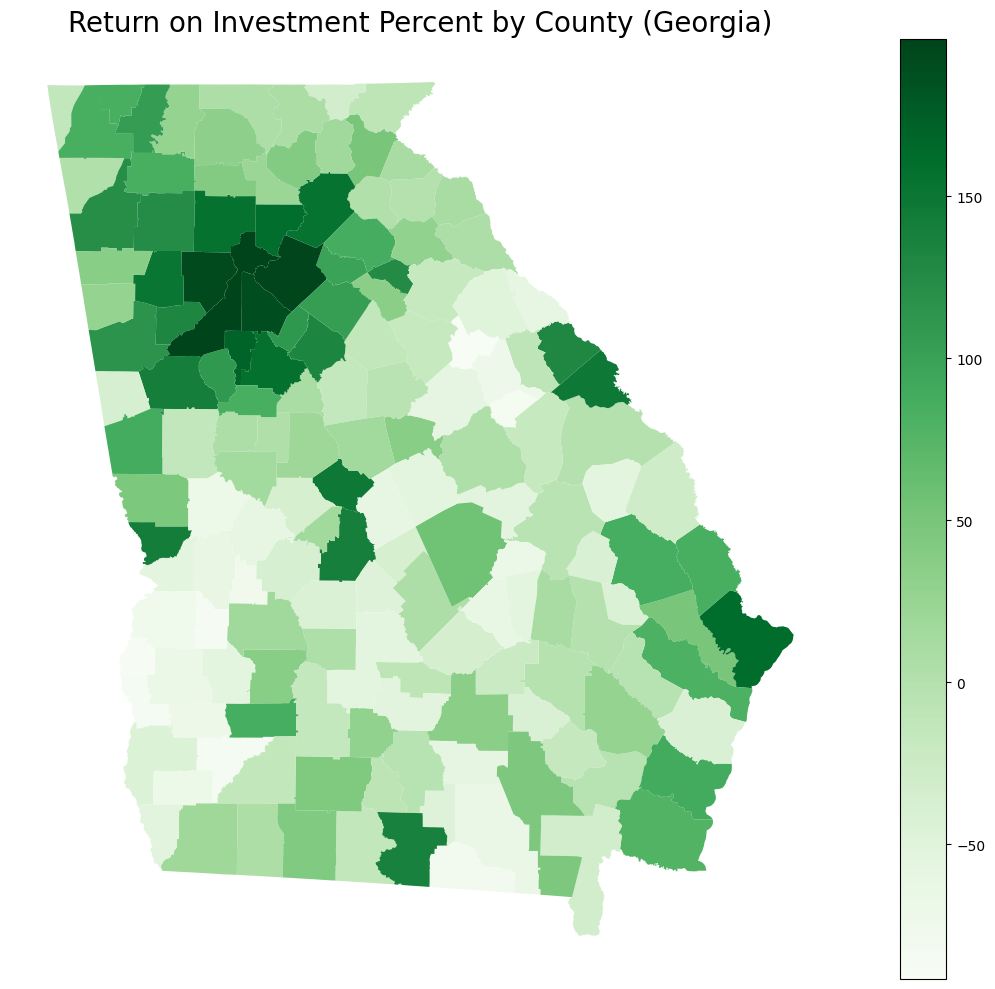

In [247]:
gdf = gpd.read_file("tl_2020_13_tract.shp")  # 13 = Georgia FIPS

gdf["geoid"] = (gdf["STATEFP"] + gdf["COUNTYFP"]).astype(int)
county_gdf = gdf.dissolve(by="geoid").reset_index()

# Merge with your county dataframe
merged = county_gdf.merge(georgia[["geoid", "roi"]], on="geoid", how="left")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
merged.plot(
    column="roi",
    ax=ax,
    legend=True,
    cmap="Greens",
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)
ax.set_title("Return on Investment Percent by County (Georgia)", fontsize=20)
ax.axis("off")
plt.tight_layout()
plt.savefig("georgia_roi.png", dpi=300, bbox_inches="tight")
plt.show()

In [239]:
county["roi_2%_adopt"] = county.apply(lambda row: FinanceCalc(
    emp_1=row["employee1_mean"],
    emp_extra=45580,
    rn=132000,
    rent=row["median_rent"],
    count=(row["total_population"]*.02),
    sub_price=100
).roi_percent(), axis=1)

county["roi_1%_adopt"] = county.apply(lambda row: FinanceCalc(
    emp_1=row["employee1_mean"],
    emp_extra=45580,
    rn=132000,
    rent=row["median_rent"],
    count=(row["total_population"]*.01),
    sub_price=100
).roi_percent(), axis=1)

county.to_csv('roi_by_county.csv')